In [1]:
!pip3 install --force-reinstall "numpy<2.0"
!pip3 install pandas matplotlib


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
  Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp39-cp39-macosx_10_9_x86_64.whl (20.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime

In [3]:
# Setting up colors for graphs

COLORS = {
	'Running':           '#f97316',
	'Treadmill Running': '#fb923c',
	'Bouldering':        '#a78bfa',
	'Strength Training': '#34d399',
	'Yoga':              '#60a5fa', # Stretching
	'Hiking':            '#fbbf24',
	'Other':             '#9ca3af',
}

I purchased my Garmin Forerunner 265 on 12/1/24, and have been logging workouts daily since then.

Recently, I discovered that Garmin allows you to easily export activities on a rolling six month window.

While the watch provides basic insights on a week-to-week basis, I wanted to dive a little deeper into how my habits have changed. I've slowly shifted away from climbing as the weather on the East Coast has started to get warmer, and been on a 4-5 day lifting schedule. I'm curious to see how my body has held up.

In [5]:
df_raw = pd.read_csv("activities.csv")

# Parsing helpers
def parse_duration(s):
	if pd.isna(s) or s == '--':
		return np.nan
	s = str(s).strip()
	p = s.split(":")
	try:
		if len(p) == 3:
			return int(p[0])*3600 + int(p[1])*60 + float(p[2])
		elif len(p) == 2:
			return int(p[0])*60 + float(p[1])
		else:
			return float(p[0])
	except IndexError:
		return np.nan

def clean(s):
	if pd.isna(s) or str(s).strip() in ('--', ''):
		return np.nan
	return pd.to_numeric(str(s).replace(',', ''), errors='coerce')

In [8]:
# Some janitor/plumbing work:

df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'])
df['date_only'] = df['Date'].dt.date
df['weekday'] = df['Date'].dt.day_name()
df['weekday_num'] = df['Date'].dt.dayofweek  # 0=Mon ... 6=Sun
df['hour'] = df['Date'].dt.hour
df['week'] = df['Date'].dt.to_period('W')
df['month'] = df['Date'].dt.to_period('M')
df['month_label'] = df['Date'].dt.strftime('%b %Y')

# Duration in minutes
df['duration_sec'] = df['Time'].apply(parse_duration)
df['duration_min'] = df['duration_sec'] / 60

for col in ['Calories', 'Avg HR', 'Max HR', 'Aerobic TE', 'Distance',
			'Total Reps', 'Total Sets', 'Total Routes']:
	df[col] = df[col].apply(clean)

# Specifics for bouldering
df['climb_time_sec'] = df['Climb Time'].apply(parse_duration)
df['rest_sec'] = df['Total Rest'].apply(parse_duration)
df['climb_ratio'] = df['climb_time_sec'] / df['duration_sec']

df['pace_sec_mi'] = df['Avg Pace'].apply(parse_duration)

# Tidy activity type labels
def simplify(t):
	if 'Running' in str(t):
		return t  # keep Treadmill vs Outdoor
	return t

df['activity_group'] = df['Activity Type'].apply(
	lambda x: x if x in COLORS else 'Other'
)

In [9]:
print(f'Loaded {len(df)} activities from {df["Date"].min().date()} to {df["Date"].max().date()}')
df[['Date','Activity Type','duration_min','Calories','Avg HR']].head(8)

Loaded 160 activities from 2025-10-12 to 2026-03-21


,Date,Activity Type,duration_min,Calories,Avg HR
0,2026-03-21 09:19:08,Running,43.650000,487,143.0
1,2026-03-20 07:42:13,Strength Training,32.000000,156,99.0
2,2026-03-19 19:04:26,Bouldering,98.866667,510,107.0
3,2026-03-19 07:11:47,Strength Training,43.983333,226,102.0
4,2026-03-17 19:29:08,Treadmill Running,41.916667,508,149.0
5,2026-03-17 06:53:49,Strength Training,69.900000,346,103.0
6,2026-03-16 07:11:29,Strength Training,60.783333,352,108.0
7,2026-03-13 17:42:40,Strength Training,18.600000,133,116.0


First, let's knock out the "Spotify Wrapped" sort of stats.
Let's start by breaking down by category what I spent the most time doing, alongside how many hours I spent.


Total hours: 154.2 hours
Total calories: 60,868 kcal
Average Workouts/Week*: 7.0 sessions


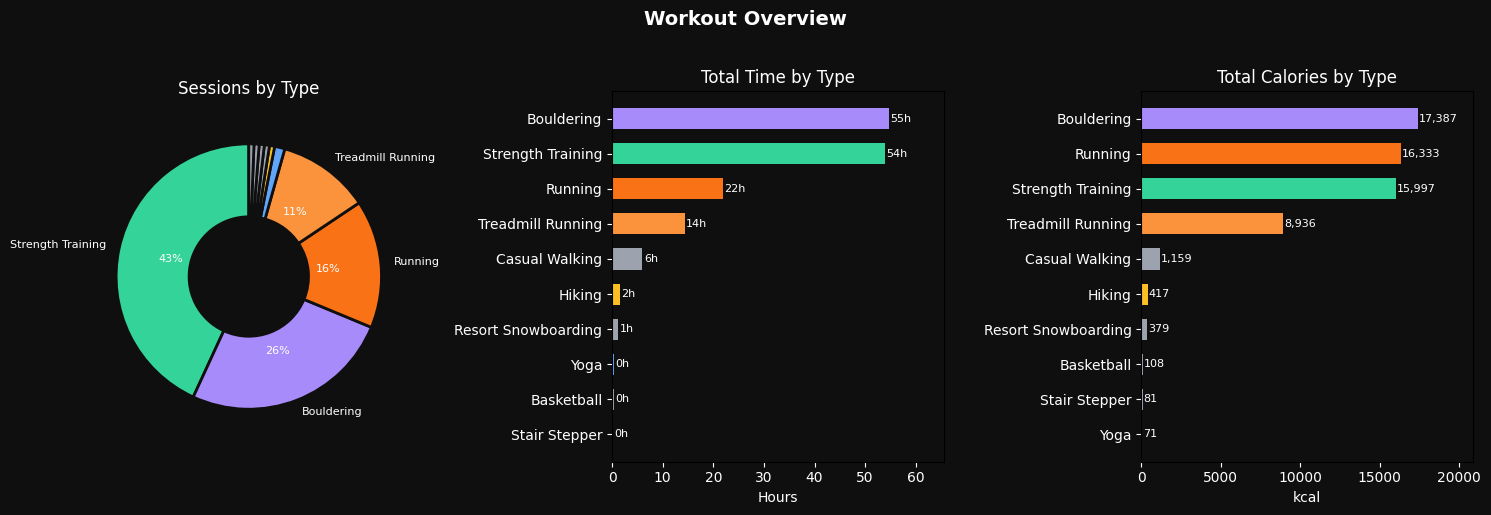

In [28]:
counts = df['Activity Type'].value_counts()
total_hours = df['duration_min'].sum() / 60
total_cals = df['Calories'].sum()
days_span = (df['Date'].max() - df['Date'].min()).days

print(f"Total hours: {total_hours:.1f} hours")
print(f"Total calories: {total_cals:,.0f} kcal")
print(f"Average Workouts/Week*: {len(df)/(days_span/7):.1f} sessions")

BG = '#0f0f0f'

total = counts.sum()
pcts = counts.values / total

def autopct(v):
	return '%1.0f%%' % v if v / 100 >= 0.02 else ''

with plt.rc_context({'axes.facecolor': BG, 'figure.facecolor': BG,
					 'text.color': 'white', 'axes.labelcolor': 'white',
					 'xtick.color': 'white', 'ytick.color': 'white'}):
	fig, axes = plt.subplots(1, 3, figsize=(15, 5))
	fig.suptitle('Workout Overview', fontsize=14, fontweight='bold', y=1.02)

	ax = axes[0]
	c_map = [COLORS.get(k, '#9ca3af') for k in counts.index]
	labels = [l if p >= 0.02 else '' for l, p in zip(counts.index, pcts)]
	wedges, texts, autotexts = ax.pie(
		counts.values, labels=labels, autopct=autopct,
		colors=c_map, startangle=90,
		wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
		textprops=dict(fontsize=8)
	)
	for at in autotexts:
		at.set_color('white')
	ax.set_title('Sessions by Type', pad=12)

	ax = axes[1]
	hrs = df.groupby('Activity Type')['duration_min'].sum().sort_values() / 60
	colors2 = [COLORS.get(k, '#9ca3af') for k in hrs.index]
	bars = ax.barh(hrs.index, hrs.values, color=colors2, height=0.6)
	for bar, val in zip(bars, hrs.values):
		ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
				f'{val:.0f}h', va='center', fontsize=8, color='white')
	ax.set_xlabel('Hours')
	ax.set_title('Total Time by Type')
	ax.set_xlim(0, hrs.max()*1.2)

	ax = axes[2]
	cal = df.groupby('Activity Type')['Calories'].sum().sort_values()
	colors3 = [COLORS.get(k, '#9ca3af') for k in cal.index]
	bars = ax.barh(cal.index, cal.values, color=colors3, height=0.6)
	for bar, val in zip(bars, cal.values):
		ax.text(val + 50, bar.get_y() + bar.get_height()/2,
				f'{val:,.0f}', va='center', fontsize=8, color='white')
	ax.set_xlabel('kcal')
	ax.set_title('Total Calories by Type')
	ax.set_xlim(0, cal.max()*1.2)

	plt.tight_layout()
	plt.show()

\* I had a period where I used to stretch after every lifting workout, which I consider to be in the same workout. Combining these workouts together seems to be a larger lift that I am willing to do.

Next, let's look for streaks and build out a heat map.

Longest streak: 13 days


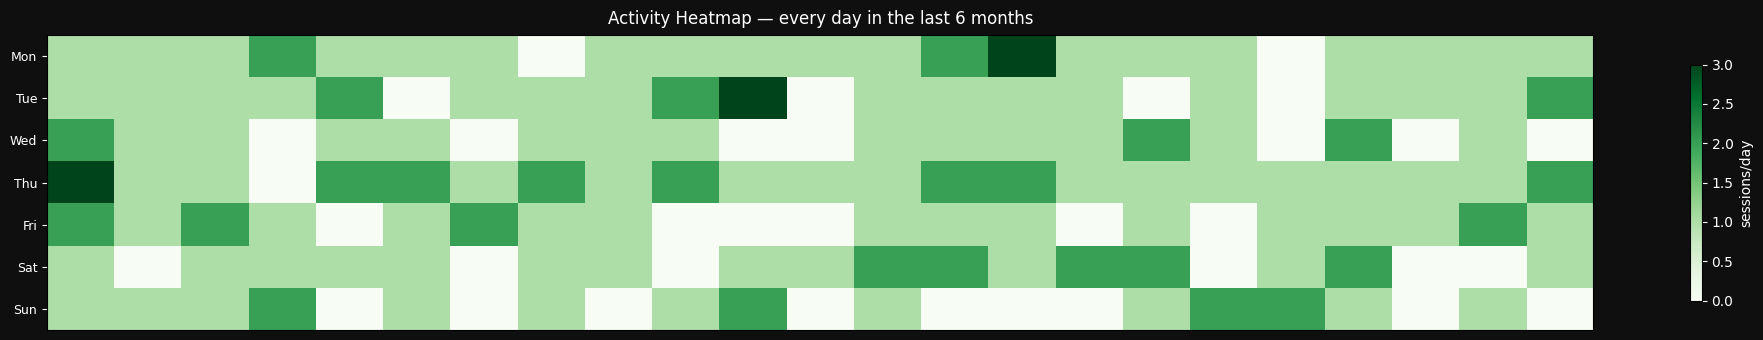

In [26]:
active_days = sorted(df['date_only'].unique())
active_set = set(active_days)

def compute_streaks(day_list):
	if not day_list:
		return []
	streaks, streak_start, prev = [], day_list[0], day_list[0]
	for d in day_list[1:]:
		if (d - prev).days == 1:
			prev = d
		else:
			streaks.append((streak_start, prev, (prev - streak_start).days + 1))
			streak_start = prev = d
	streaks.append((streak_start, prev, (prev - streak_start).days + 1))
	return streaks

all_streaks = compute_streaks(active_days)
longest = max(all_streaks, key=lambda x: x[2])

print(f"Longest streak: {longest[2]} days")

date_range = pd.date_range(df['Date'].min().date(), df['Date'].max().date())
cal_df = pd.DataFrame({'date': date_range})
counts_per_day = df.groupby('date_only').size().reset_index(name='n')
counts_per_day['date_only'] = pd.to_datetime(counts_per_day['date_only'])
cal_df = cal_df.merge(counts_per_day, left_on='date', right_on='date_only', how='left').fillna(0)
cal_df['week_num'] = (cal_df['date'] - cal_df['date'].min()).dt.days // 7
cal_df['dow'] = cal_df['date'].dt.dayofweek

pivot = cal_df.pivot_table(index='dow', columns='week_num', values='n', aggfunc='sum').fillna(0)

BG = '#0f0f0f'
with plt.rc_context({'axes.facecolor': BG, 'figure.facecolor': BG,
					 'text.color': 'white', 'axes.labelcolor': 'white',
					 'xtick.color': 'white', 'ytick.color': 'white'}):
	fig, ax = plt.subplots(figsize=(20, 3.5))
	im = ax.imshow(pivot.values, aspect='auto', cmap=plt.cm.Greens, vmin=0, vmax=3,
				   interpolation='nearest')
	ax.set_yticks(range(7))
	ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], fontsize=9)
	ax.set_xticks([])
	ax.set_title('Activity Heatmap — every day in the last 6 months', pad=8)
	cb = plt.colorbar(im, ax=ax, label='sessions/day', shrink=0.8)
	cb.ax.yaxis.set_tick_params(color='white')
	plt.tight_layout()
	plt.show()

Next, let's check how long each workout generally is, alongside the volume. I would not put too much value in this one given that I sometimes forget to stop the workout immediately after a session (typically for strength + bouldering workouts) so this may skew a bit higher than what reality.

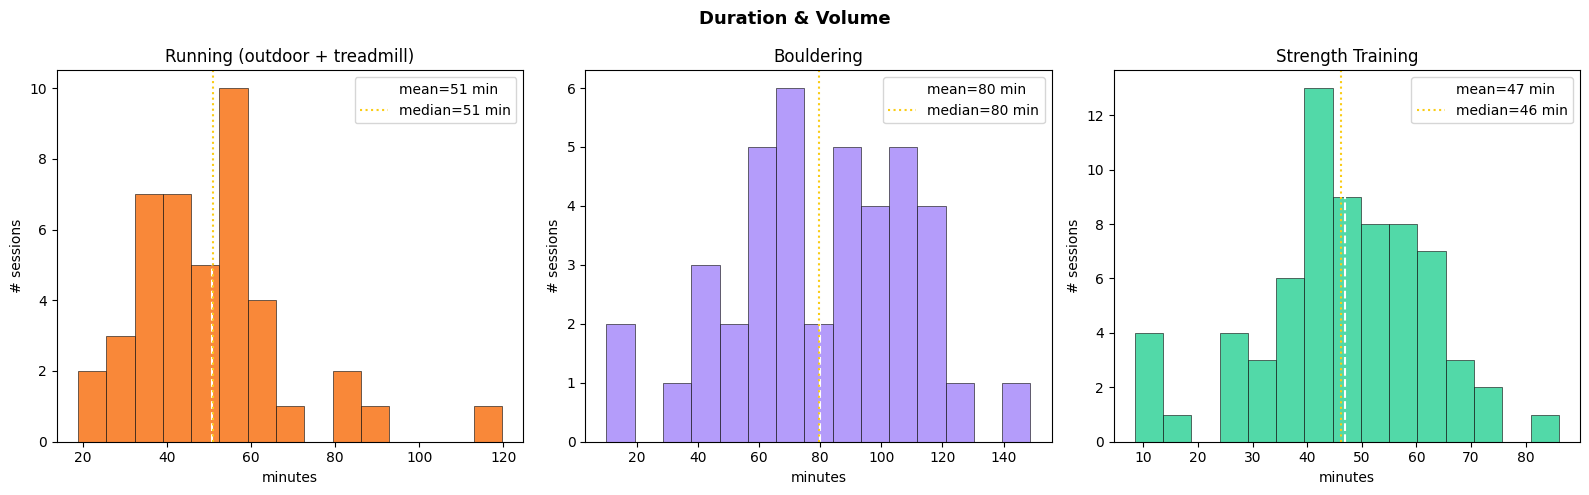

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Duration & Volume', fontsize=13, fontweight='bold')

for ax, atype, label in zip(
	axes,
	['Running', 'Bouldering', 'Strength Training'],
	['Running (outdoor + treadmill)', 'Bouldering', 'Strength Training']
):
	if atype == 'Running':
		sub = df[df['Activity Type'].str.contains('Running')]['duration_min'].dropna()
		color = COLORS['Running']
	else:
		sub = df[df['Activity Type'] == atype]['duration_min'].dropna()
		color = COLORS[atype]

	ax.hist(sub, bins=15, color=color, alpha=0.85, edgecolor='#0f0f0f', linewidth=0.5)
	ax.axvline(sub.mean(), color='white', lw=1.5, linestyle='--', label=f'mean={sub.mean():.0f} min')
	ax.axvline(sub.median(), color='#facc15', lw=1.5, linestyle=':', label=f'median={sub.median():.0f} min')
	ax.set_xlabel('minutes')
	ax.set_ylabel('# sessions')
	ax.set_title(label)
	ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

dur_summary = df.groupby('Activity Type')['duration_min'].agg(['mean','median','min','max','count'])
dur_summary.columns = ['Mean (min)','Median (min)','Min (min)','Max (min)','Sessions']
dur_summary = dur_summary.round(1)